# Axolotl dataset expriments

In [1]:
import scanpy as sc
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
import phate
import sys
from tqdm import tqdm

# Import the modules themselves
import torchcfm.conditional_flow_matching as cfm
import torchcfm.models as models
import torchcfm.utils as utils
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [2]:
folder_path = "/home/mcb/users/msandl4/data/axolotl/"

Read all the hd5 files

In [3]:
from pathlib import Path
import re
folder = Path(folder_path)


In [4]:

def extract_daynum(f):
    """Extract leading number from filename stem like '2DPI_1' -> 2, '10DPI_1' -> 10"""
    match = re.match(r'(\d+)', f.stem)
    if match:
        return int(match.group(1))
    else:
        return float('inf')

files = sorted(folder.glob("*.h5ad"), key=extract_daynum)
adatas = [sc.read_h5ad(f) for f in files]

batch_numbers = [extract_daynum(f) for f in files]

adata_merged = sc.concat(adatas,
                         join='outer',              # keep all genes
                         label='timepoint',         # name of column for day/time
                         keys=batch_numbers,        # numeric day labels
                         fill_value=0)

/home/mcb/users/msandl4/.conda/envs/torchcfm/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


run PCA embeddings, and then phate embeddings 

In [5]:
sc.pp.normalize_total(adata_merged, target_sum=1e4)
sc.pp.log1p(adata_merged)
sc.pp.highly_variable_genes(adata_merged, n_top_genes=2000, flavor='seurat', batch_key='timepoint')
adata_merged = adata_merged[:, adata_merged.var['highly_variable']]
sc.pp.scale(adata_merged, max_value=10)

sc.tl.pca(adata_merged, svd_solver='arpack')


import phate
phate_operator = phate.PHATE(n_components=2)
adata_merged.obsm['X_phate'] = phate_operator.fit_transform(adata_merged.X)

/home/mcb/users/msandl4/.conda/envs/torchcfm/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/mcb/users/msandl4/.conda/envs/torchcfm/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/mcb/users/msandl4/.conda/envs/torchcfm/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Calculating PHATE...
  Running PHATE on 44672 observations and 2000 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 3.64 seconds.
    Calculating KNN search...
    Calculated KNN search in 1.78 seconds.
    Calculating affinities...
    Calculated affinities in 3.62 seconds.
  Calculated graph and diffusion operator in 9.24 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 7.04 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.01 seconds.
  Calculated landmark operator in 9.06 seconds.
  Calculating optimal t...
    Automatically selected t = 29
  Calculated optimal t in 1.09 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.24 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.66 seconds.
Calculated PHATE in 23.71 seconds.


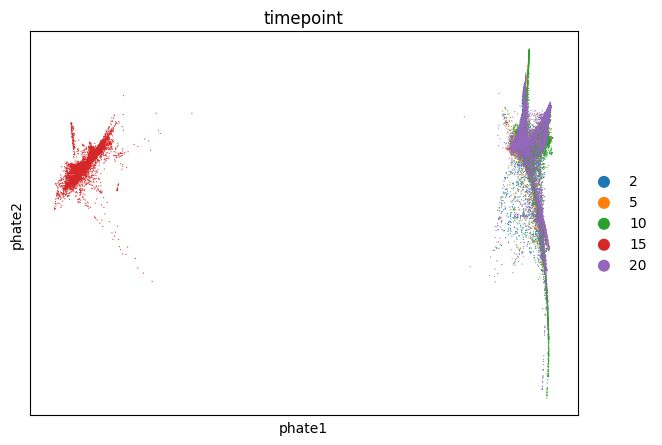

In [6]:
sc.pl.scatter(adata_merged, basis="phate", color="timepoint")

In [7]:
adata_merged.obs["timepoint"]
timepoints = sorted(adata_merged.obs['timepoint'].unique())
print(timepoints)
n_times = len(timepoints)
# Standardize coordinates
coords = adata_merged.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata_merged.obsm["X_phate_standardized"] = coords
X = [
    adata_merged.obsm["X_phate_standardized"][adata_merged.obs["timepoint"] == t]
    for t in timepoints
]

[2, 5, 10, 15, 20]


9440 cells, 27,600 genes

In [8]:
import scprep


def plot_trajectories(traj, legend=True):
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata_merged.obsm["X_phate_standardized"][:, 0],
        adata_merged.obsm["X_phate_standardized"][:, 1],
        title = "CFM trajectories",
        c=adata_merged.obs["timepoint"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")


def get_batch(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with point sfrom each timepoint pair"""
    ts = []
    xts = []
    uts = []
    noises = []
    for t_start in range(n_times - 1):
        x0 = (
            torch.from_numpy(X[t_start][np.random.randint(X[t_start].shape[0], size=batch_size)])
            .float()
            .to(device)
        )
        x1 = (
            torch.from_numpy(
                X[t_start + 1][np.random.randint(X[t_start + 1].shape[0], size=batch_size)]
            )
            .float()
            .to(device)
        )
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, return_noise=return_noise)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut

In [9]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
n_times = len(timepoints)

In [10]:
def train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000):
    for i in tqdm(range(10000)):
        ot_cfm_optimizer.zero_grad()
        t, xt, ut = get_batch(FM, X, batch_size, n_times)
        vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        ot_cfm_optimizer.step()

In [11]:
def plot_node_path(ot_cfm_model, X):
    node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
    with torch.no_grad():
        traj = node.trajectory(
            torch.from_numpy(X[0][:1000]).float().to(device),
            t_span=torch.linspace(0, n_times - 1, 400),
        ).cpu()
        plot_trajectories(traj.cpu().numpy())

In [12]:

sigma = 0.3
dim = adata_merged.obsm["X_phate_standardized"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="exact")

In [13]:
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [06:34<00:00, 25.36it/s]


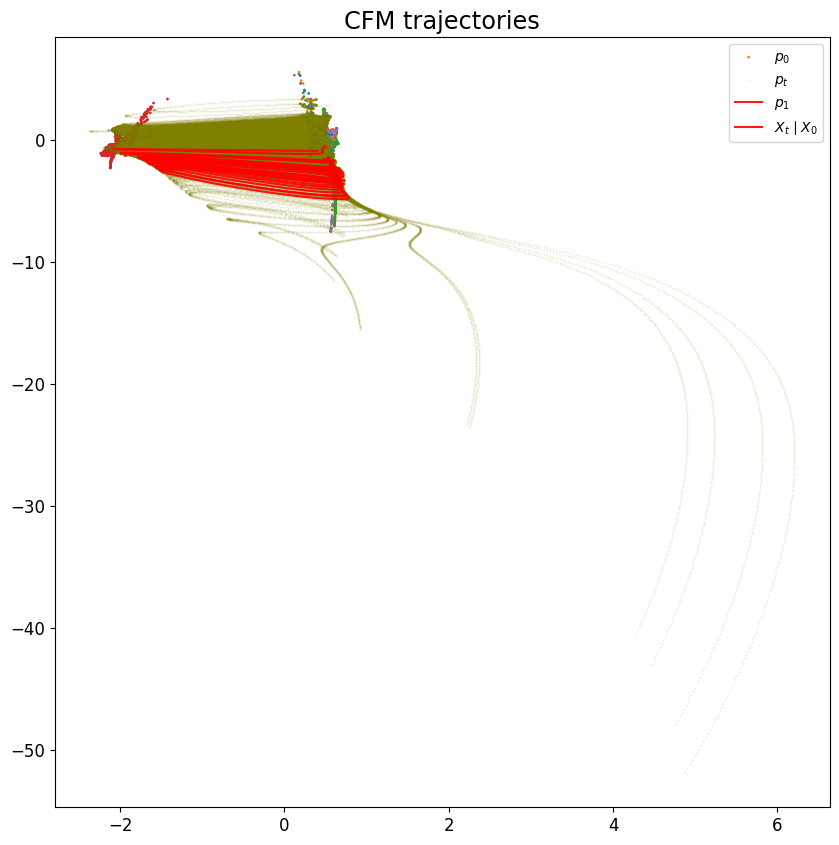

In [14]:
plot_node_path(ot_cfm_model, X)

In [15]:
sigma = 0.3
dim = adata_merged.obsm["X_phate_standardized"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="prior", prior_method="basic_entropic_ot")
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:16<00:00, 73.13it/s]


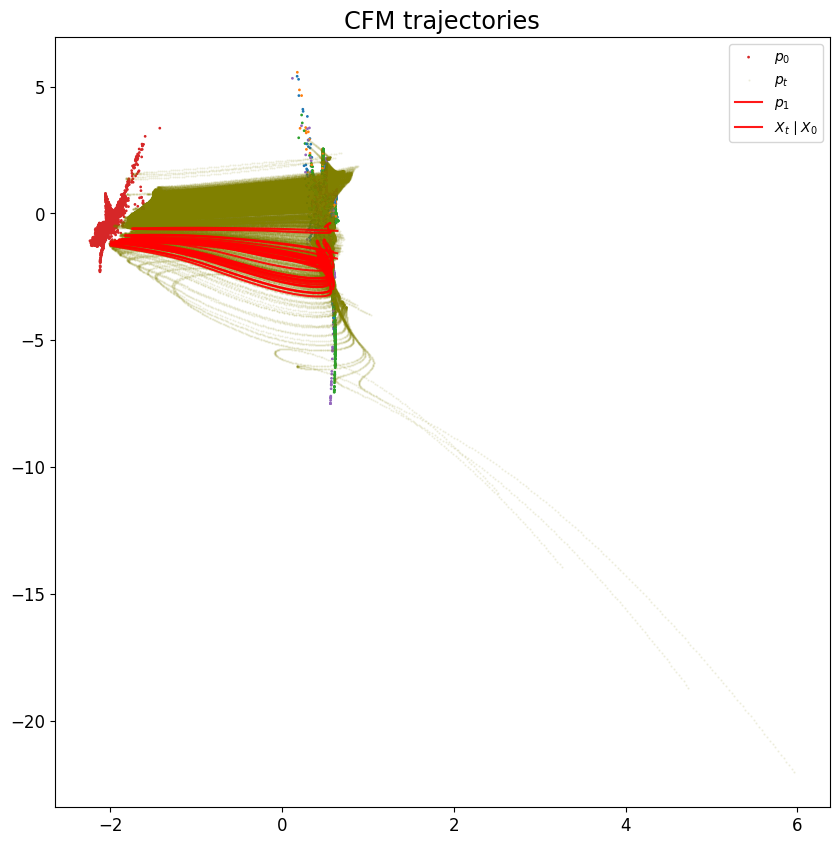

In [16]:
plot_node_path(ot_cfm_model, X)

# Spatial info

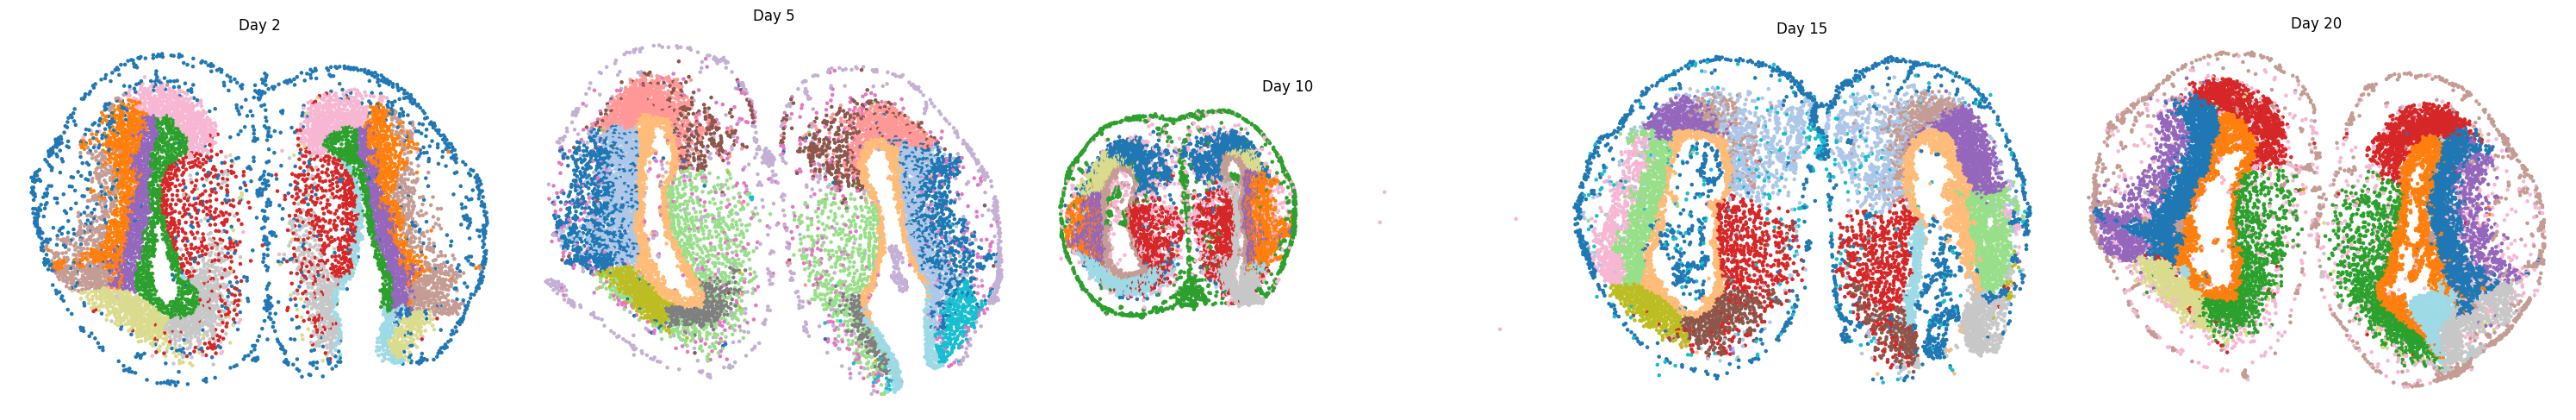

In [17]:
time_data = [adata_merged[adata_merged.obs['timepoint'] == tp] for tp in timepoints]

# Create subplots
fig, axes = plt.subplots(1, len(timepoints), figsize=(6*len(timepoints), 6))

for ax, adata_tp, label in zip(axes, time_data, timepoints):
    # Get spatial coordinates
    coords = adata_tp.obsm['spatial']
    
    # Color by cluster/cell type if available
    if 'spatial_leiden_e30_s8' in adata_tp.obs.columns:
        c = adata_tp.obs['spatial_leiden_e30_s8'].astype(int)
    else:
        c = None
    
    ax.scatter(coords[:, 0], coords[:, 1], c=c, s=5, cmap='tab20')
    ax.set_title(f"Day {label}")
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
time_data = [adata_merged[adata_merged.obs['timepoint'] == tp] for tp in timepoints]
from sklearn.metrics import pairwise_distances


def get_batch_spatial(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with point sfrom each timepoint pair"""
    ts = []
    xts = []
    uts = []
    Ds = []
    noises = []
    coords = [adata_t.obsm["spatial"] for adata_t in time_data]
    for t_start in range(n_times - 1):
        idx0 = np.random.randint(X[t_start].shape[0], size=batch_size)
        idx1 = np.random.randint(X[t_start+1].shape[0], size=batch_size)

        x0 = torch.from_numpy(X[t_start][idx0]).float().to(device)
        x1 = torch.from_numpy(X[t_start+1][idx1]).float().to(device)

        c0 = coords[t_start][idx0]
        c1 = coords[t_start+1][idx1]
        
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
             # compute spatial prior
            D = pairwise_distances(c0, c1)
            # sample conditional flow
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, D=D)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    #Ds = torch.stack(Ds)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut




In [14]:
def train_model_custom_prior(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000):
    for i in tqdm(range(10000)):
        ot_cfm_optimizer.zero_grad()
        t, xt, ut = get_batch_spatial(FM, X, batch_size, n_times)
        vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        ot_cfm_optimizer.step()

In [15]:
sigma = 0.3
dim = adata_merged.obsm["X_phate_standardized"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="prior", prior_method="spatial")
train_model_custom_prior(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:22<00:00, 49.40it/s]


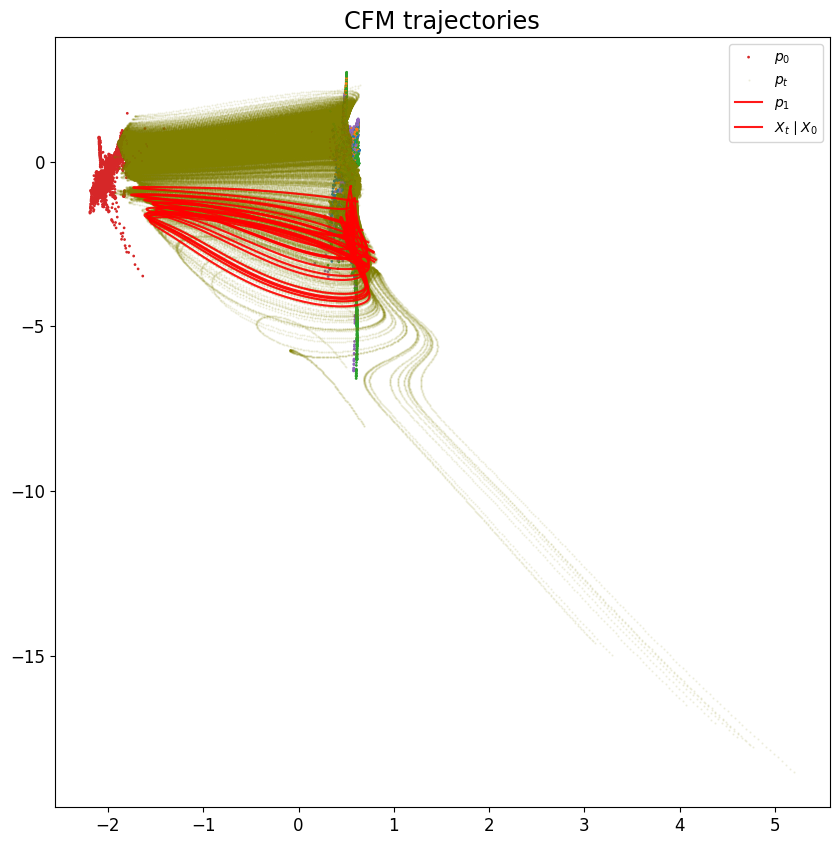

In [16]:
plot_node_path(ot_cfm_model, X)

In [ ]:
def plot_trajectories_cell_type(traj, legend=True):

    ##!TO DO
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata_merged.obsm["X_phate_standardized"][:, 0],
        adata_merged.obsm["X_phate_standardized"][:, 1],
        title = "CFM trajectories",
        c=adata_merged.obs["timepoint"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")

